## Modern Time Series (Pop Mart Case Study)
### Yilin Luo

### Table of Contents

1. Introduction
2. Data Preparation
    - 2.1 Load and preview raw data
    - 2.2 clean and prepare the dataset
4. Exploratory Data Analysis
    - 3.1 Summary Statistics
    - 3.2 Raw Price Series
    - 3.3 Daily Return (% Change)
    - 3.4 Rolling Volatility
    - 3.5 EDA Summary & Modeling Strategy 
5. Modeling and Anomaly Detection
    - 4.1 Simple Moving Average (SMA)
    - 4.2 Exponential Smoothing (ES)
    - 4.3 Seasonal-Trend Decomposition (STL)
    - 4.4 Prophet Forecasting Model
6. Conclusion

### 1. Introduction

In this project, I analyze the historical stock price of Pop Mart, collected from Yahoo Finance, covering June 13, 2022, to June 13, 2025, with daily trading data for each business day. 

In recent years, Pop Mart has experienced rapid growth, largely driven by the popularity of its intellectual property (IP) product lines such as Labubu and other collectible figures, contributing to a sharp and sustained increase in stock price. While the raw price series exhibits nonlinear growth without clear seasonal patterns, exploratory data analysis showed that the daily return series is more stationary and better suited for decomposition and forecasting models. Therefore, Simple Moving Average (SMA) is applied to the raw price to detect level-based anomalies, while Exponential Smoothing (ES), Seasonal-Trend Decomposition (STL), and Prophet models are applied to the daily returns to capture relative deviations and volatility changes. The project follows a complete pipeline of data preparation, exploratory analysis, model fitting, anomaly detection, and interpretation.

### 2. Data Preparation

In the data preparation,  the daily Pop Mart stock price dataset, originally obtained from Yahoo Finance, was loaded from a local CSV file. To ensure data consistency, column names were cleaned by removing any leading or trailing spaces. Dividend rows and other non-trading records were filtered out by excluding rows with missing values in the ‘Adj Close’ price column. The ‘Date’ column was then converted to proper datetime format, using the format %d-%b-%y to correctly parse dates such as 13-Jun-25. The ‘Date’ column was set as the index to establish a time series structure. Finally, only the ‘Adjusted Close’ price was retained for analysis and modeling, as it reflects stock prices adjusted for corporate actions such as dividends and stock splits.

### 2.1 Load and preview raw data

In [1]:
# Install required packages if not already installed
# import sys
#!{sys.executable} -m pip install pandas numpy matplotlib seaborn statsmodels prophet

import pandas as pd
import numpy as np

In [40]:
# Load the daily Pop Mart dataset from CSV file
file_path = 'Pop_Mart.csv'
df = pd.read_csv(file_path)

# Display the first five rows to preview raw data
print("Preview of raw data:")
print(df.head(10))

# Display the number of rows and columns in the dataset
rows, cols = df.shape
print(f"The dataset contains {rows} rows and {cols} columns.")

# Display the raw column names
print("Columns in raw dataset:", df.columns.tolist())

Preview of raw data:
        Date   Open   High    Low  Close   Adj Close       Volume
0  13-Jun-25    267  276.2  263.6   272.6       272.6  16,512,370
1  12-Jun-25  273.8  283.4  266.6   266.8       266.8  26,362,272
2  11-Jun-25  261.6  269.8  250.2   269.8       269.8  18,342,406
3  10-Jun-25    253  262.0  250.6   258.8       258.8  14,824,005
4   9-Jun-25  251.2  253.0  242.0   250.8       250.8  12,279,461
5   6-Jun-25  243.2  248.6  239.4   244.8       244.8   9,719,916
6   5-Jun-25    249  252.6  238.0   243.0       243.0  17,985,477
7   4-Jun-25    234  248.8  234.0   246.0       246.0  14,472,197
8   3-Jun-25    231  235.6  225.2   234.0       234.0  12,361,361
9   2-Jun-25  223.6  233.0  222.2   230.0       230.0   6,491,406
The dataset contains 741 rows and 7 columns.
Columns in raw dataset: ['Date', 'Open', 'High', 'Low', 'Close\xa0', 'Adj Close\xa0', 'Volume']


### 2.2 Clean and prepare the dataset

In [3]:
# Clean column names by stripping leading/trailing spaces
df.columns = df.columns.str.strip()

# Convert 'Date' column to datetime format (use exact format)
df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%y')

# Remove dividend rows (keep only rows where 'Open' price exists)
df = df[df['Adj Close'].notna()]

# Set 'Date' as index to create a time series structure
df = df.set_index('Date')

# Select only 'Adjusted Close' column for analysis
df = df[['Adj Close']]

# Preview cleaned data
print("Preview of cleaned data:")
print(df.head(24)) # one month 

# Print cleaned dataset dimensions
rows, cols = df.shape
print(f"The cleaned dataset contains {rows} rows and {cols} column.")

Preview of cleaned data:
            Adj Close
Date                 
2025-06-13    272.600
2025-06-12    266.800
2025-06-11    269.800
2025-06-10    258.800
2025-06-09    250.800
2025-06-06    244.800
2025-06-05    243.000
2025-06-04    246.000
2025-06-03    234.000
2025-06-02    230.000
2025-05-30    220.400
2025-05-29    225.000
2025-05-28    215.785
2025-05-27    232.323
2025-05-26    220.368
2025-05-23    218.973
2025-05-22    222.361
2025-05-21    215.188
2025-05-20    207.417
2025-05-19    206.221
2025-05-16    194.964
2025-05-15    196.060
2025-05-14    192.972
2025-05-13    192.075
The cleaned dataset contains 738 rows and 1 column.


### 3. Exploratory Data Analysis (EDA)

In this section, we conduct an exploratory analysis of the Pop Mart stock price to understand the overall distribution, trends, variability, and volatility before applying anomaly detection models. This process informs our modeling choices for the following stages.

In [4]:
import matplotlib.pyplot as plt
import numpy as np

### 3.1 Summary statistics

In [5]:
print("Summary statistics of Adjusted Close price:")
print(df.describe())

Summary statistics of Adjusted Close price:
       Adj Close
count  738.00000
mean    47.15035
std     49.82674
min      9.97800
25%     19.03200
50%     23.53500
75%     47.60750
max    272.60000


Finding:

The adjusted closing price has a wide range from approximately 10 HKD to 273 HKD, with a mean of 47.15 HKD. The large standard deviation (49.83) indicates significant variability in price over the three-year period.

### 3.2 Raw Daily Price Series

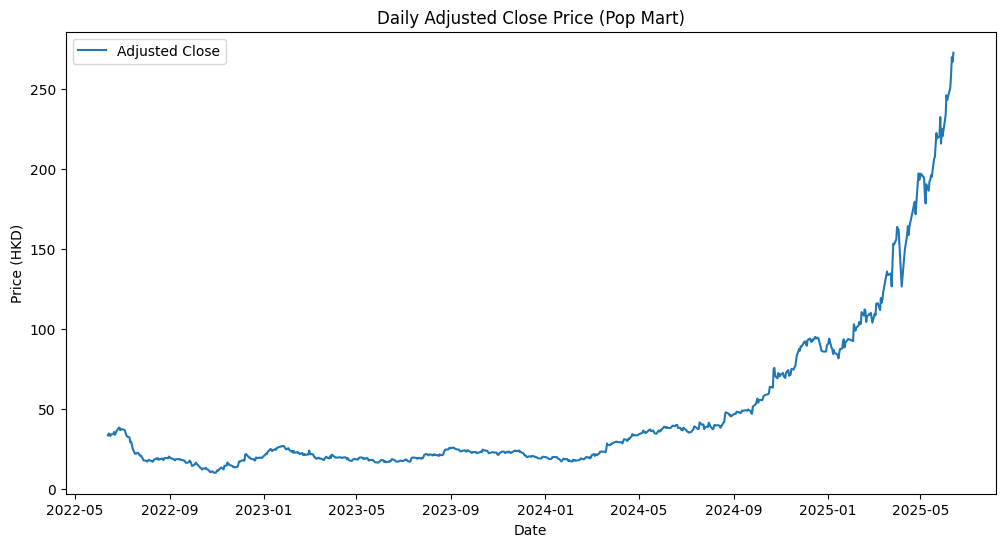

In [6]:
# Plot the raw daily price series

plt.figure(figsize=(12,6))
plt.plot(df['Adj Close'], label='Adjusted Close')
plt.title('Daily Adjusted Close Price (Pop Mart)')
plt.xlabel('Date')
plt.ylabel('Price (HKD)')
plt.legend()
plt.show()

Finding:

The raw time series shows a long period of relatively stable prices between 2022 and early 2024, followed by a sharp and accelerating growth starting in mid-2024 and continuing into 2025. This non-linear growth suggests underlying business changes or external factors influencing Pop Mart’s valuation, such as the success of its IP products like Labubu and related collectible product lines.

### 3.3 Daily Returns (% Change)

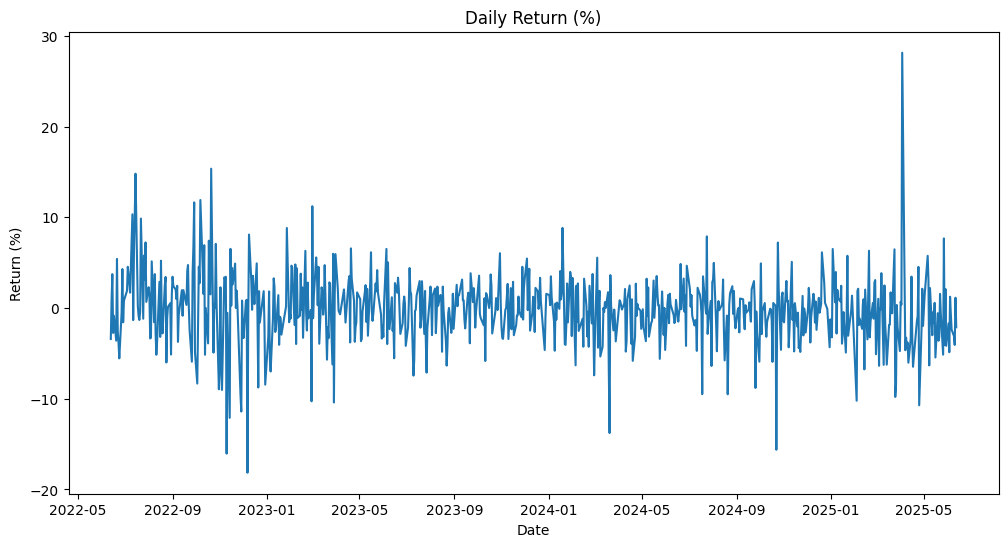

In [7]:
# Daily returns (% change)

df['Daily Return (%)'] = df['Adj Close'].pct_change() * 100

plt.figure(figsize=(12,6))
plt.plot(df['Daily Return (%)'])
plt.title('Daily Return (%)')
plt.xlabel('Date')
plt.ylabel('Return (%)')
plt.show()

Finding:

The daily returns exhibit higher fluctuations during the earlier stable price period. Although the raw price accelerates dramatically after 2024, the relative daily returns become more stabilized, with a few sharp spikes. This transformation reduces the non-stationarity of the series and reveals potential hidden patterns. Notably, this structure suggests that return-based models may better capture seasonality or anomaly signals than raw price models.

### 3.4 Rolling Volatility (24-Day Rolling Standard Deviation)

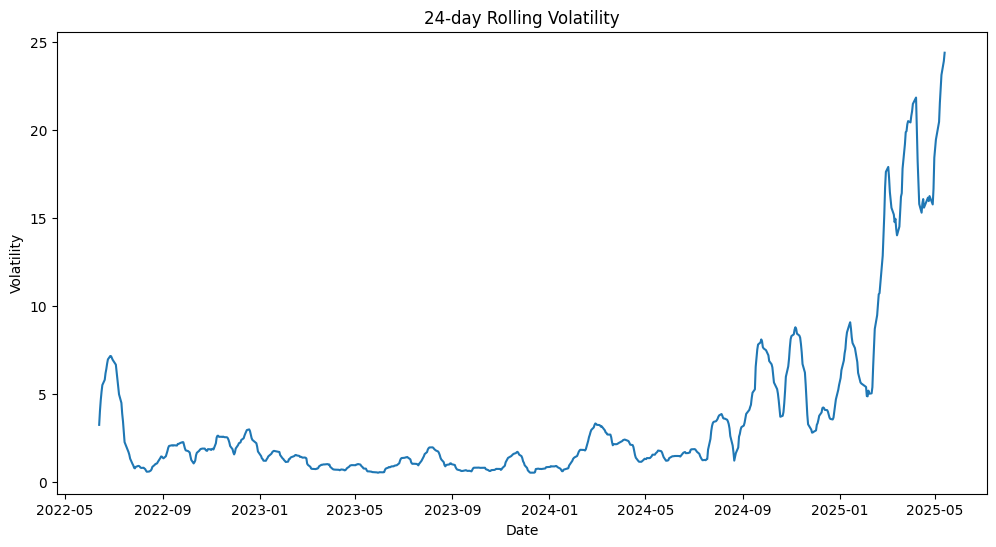

In [8]:
# Calculate rolling volatility
df['Rolling Volatility'] = df['Adj Close'].rolling(window=24).std()

# Drop NaN rows for plotting
rolling_vol_clean = df['Rolling Volatility'].dropna()

plt.figure(figsize=(12,6))
plt.plot(rolling_vol_clean)
plt.title('24-day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()

Finding:

Volatility remained relatively low from 2022 to mid-2024, followed by a rapid increase starting in late 2024 that corresponds with the strong price acceleration period. This dynamic behavior of volatility confirms that static threshold anomaly detection may not be sufficient and motivates the use of rolling or adaptive thresholds for SMA modeling. 

### 3.5 EDA Summary & Modeling Strategy

Based on the above findings, we use different subset datasets and created specific feature for anomaly detection based on the characteristics of the data.

- Simple Moving Average (SMA) and Prophet models are applied directly to the raw adjusted closing price to capture price-level anomalies and detect long-term trend shifts.
	- For SMA, we use the full 3-year daily adjusted close data to capture the overall growth trajectory.
	- For Prophet, we focus on a recent 1-year subset (2024–2025), where sharp price increases are observed, allowing the model to capture recent fluctuations and structural changes more effectively.

- Exponential Smoothing (ES) and Seasonal-Trend Decomposition (STD) models are applied to the daily return series, which exhibits more stationary properties and allows for better detection of short-term fluctuations, seasonal patterns, and residual-based anomalies.

### 4. Modeling and Anomaly Detection

### 4.1 Simple Moving Average (SMA)

Part 1: SMA Model with Adaptive Rolling Standard Deviation

In [10]:
# Make a copt for SMA analysis
sma = df.copy()

# Calculate 24-day Simple Moving Average (SMA)
sma['SMA'] = sma['Adj Close'].rolling(window=24).mean()

# Calculate residuals (difference between actual price and SMA)
sma['diff'] = sma['Adj Close'] - sma['SMA']

# Calculate adaptive rolling standard deviation of residuals
sma['rolling_std'] = sma['diff'].rolling(window=24).std()

# Build adaptive prediction bands (±2 standard deviations)
sma['upper'] = sma['SMA'] + 2 * sma['rolling_std']
sma['lower'] = sma['SMA'] - 2 * sma['rolling_std']

# Label anomalies where actual price falls outside adaptive bands
sma['anomaly'] = (sma['Adj Close'] > sma['upper']) | (sma['Adj Close'] < sma['lower'])

# Drop rows with incomplete rolling calculations for cleaner analysis
sma = sma.dropna(subset=['SMA', 'rolling_std'])

Part 2: Visualization of SMA Anomaly Detection

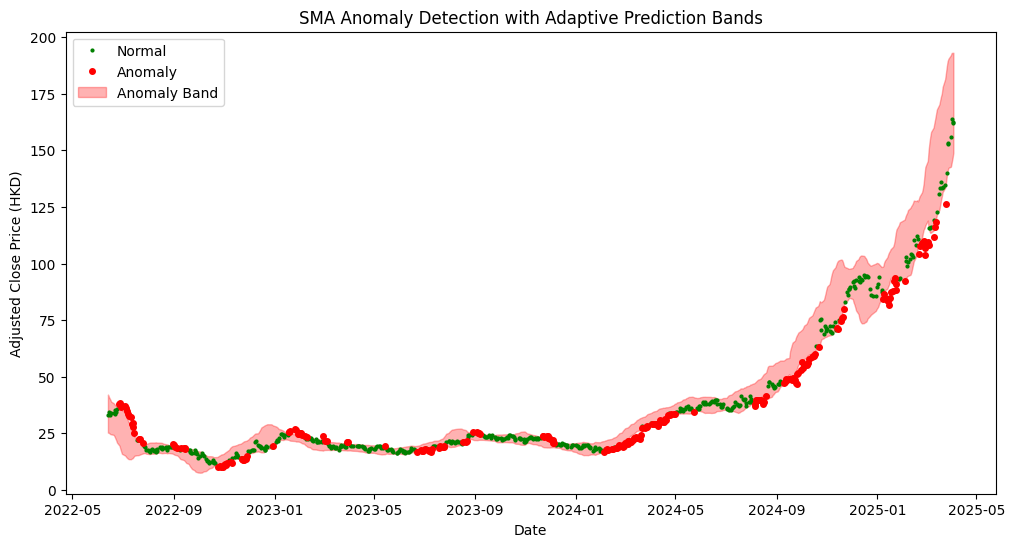

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot normal (non-anomalous) points
plt.plot(
    sma.index[sma['anomaly'] == False], 
    sma['Adj Close'][sma['anomaly'] == False], 
    'go', markersize=2, label='Normal'
)

# Plot anomalous points
plt.plot(
    sma.index[sma['anomaly'] == True], 
    sma['Adj Close'][sma['anomaly'] == True], 
    'ro', markersize=4, label='Anomaly'
)

# Fill adaptive anomaly band
plt.fill_between(
    sma.index, 
    sma['lower'], 
    sma['upper'], 
    color='red', alpha=0.3, label='Anomaly Band'
)

plt.title("SMA Anomaly Detection with Adaptive Prediction Bands")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price (HKD)")
plt.legend()
plt.show()

Part 3: Extract and Display Detected Anomalies

In [12]:
# Extract anomaly rows
df_outliers_sma = sma[sma['anomaly'] == True]

# Display anomaly table
df_outliers_sma

,Adj Close,Daily Return (%),Rolling Volatility,SMA,diff,rolling_std,upper,lower,anomaly
Date,,,,,,,,,
2025-03-25,126.423,-9.808020,19.873136,159.854875,-33.431875,12.128633,184.112141,135.597609,True
2025-03-13,118.453,-3.411695,14.378902,142.869000,-24.416000,11.563834,165.996669,119.741331,True
2025-03-12,116.261,-1.850523,14.950804,141.104833,-24.843833,11.401451,163.907736,118.301931,True
2025-03-10,111.678,-6.271087,15.191111,137.281708,-25.603708,11.377628,160.036965,114.526452,True
2025-03-04,108.291,-6.373689,17.282338,132.856708,-24.565708,8.613569,150.083846,115.629571,True
...,...,...,...,...,...,...,...,...,...
2022-07-04,36.926,1.898560,6.662072,24.754083,12.171917,4.791990,34.338063,15.170103,True
2022-06-30,37.220,0.796187,6.938825,25.575750,11.644250,4.805971,35.187691,15.963809,True
2022-06-29,36.631,-1.582483,7.035083,26.397417,10.233583,4.660019,35.717454,17.077380,True


Model Justification:

The SMA model with adaptive rolling standard deviation successfully identified 216 anomalies in the Pop Mart stock price over the three-year period. Many of these anomalies occurred during sharp price increases in 2024 and 2025, reflecting Pop Mart’s rapid growth driven by strong demand for its collectible IP products. The model works well for this type of data because it smooths out short-term fluctuations to capture the overall trend, while the adaptive standard deviation adjusts to changing volatility levels. By using a threshold of two times the recent variation, the model effectively highlights significant price jumps or drops while ignoring normal day-to-day changes, making it suitable for detecting unusual behavior in stock prices without clear seasonal patterns.

### 4.2 Exponential Smoothing

In [13]:
# import sys
# !{sys.executable} -m pip install scikit-learn

import numpy as np
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

Part 1: Prepare the Dataset for Exponential Smoothing

In [14]:
# Make a copy of df for Exponential Smoothing modeling
es = df.copy()

# Keep only Daily Return column, drop any NaN
es = es[['Daily Return (%)']].dropna()

# Rename column for consistency
es.rename(columns={'Daily Return (%)': 'return_pct'}, inplace=True)

# Preview dataset
es.head()

,return_pct
Date,
2025-06-12,-2.127660
2025-06-11,1.124438
2025-06-10,-4.077094
2025-06-09,-3.091190
2025-06-06,-2.392344


Part 2: Fit Exponential Smoothing with initial Alpha

/opt/anaconda3/envs/Anomalydetection/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/Anomalydetection/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


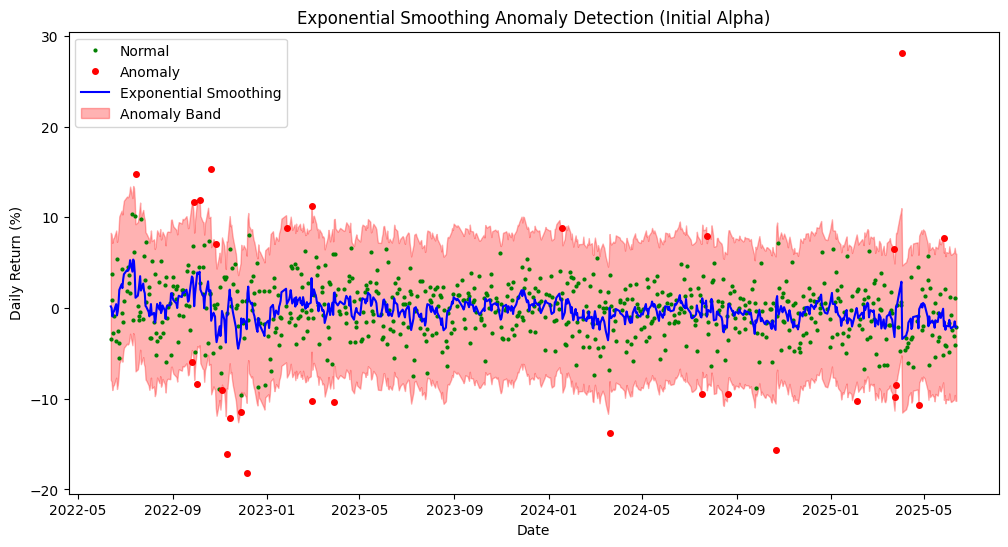

In [15]:
# Apply initial Exponential Smoothing (alpha=0.2 as starting point)
model = SimpleExpSmoothing(es['return_pct']).fit(smoothing_level=0.2, optimized=False)

# Generate smoothed values
es['smoothed'] = model.fittedvalues

# Calculate residuals
es['residual'] = es['return_pct'] - es['smoothed']

# Calculate standard deviation of residuals
residual_std = es['residual'].std()

# Build adaptive anomaly bands (±2 std)
es['upper'] = es['smoothed'] + 2 * residual_std
es['lower'] = es['smoothed'] - 2 * residual_std

# Identify anomalies
es['anomaly'] = (es['return_pct'] > es['upper']) | (es['return_pct'] < es['lower'])

# Visualize initial result
plt.figure(figsize=(12,6))

# Plot normal
plt.plot(es.index[es['anomaly'] == False], es['return_pct'][es['anomaly'] == False], 'go', markersize=2, label='Normal')
# Plot anomalies
plt.plot(es.index[es['anomaly'] == True], es['return_pct'][es['anomaly'] == True], 'ro', markersize=4, label='Anomaly')
# Plot smoothing curve
plt.plot(es.index, es['smoothed'], 'b-', label='Exponential Smoothing')
# Fill anomaly bands
plt.fill_between(es.index, es['lower'], es['upper'], color='red', alpha=0.3, label='Anomaly Band')

plt.title("Exponential Smoothing Anomaly Detection (Initial Alpha)")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")
plt.legend()
plt.show()

Part 3: Tune Alpha via Grid Search

Best alpha: 0.0400, MSE: 26.5065


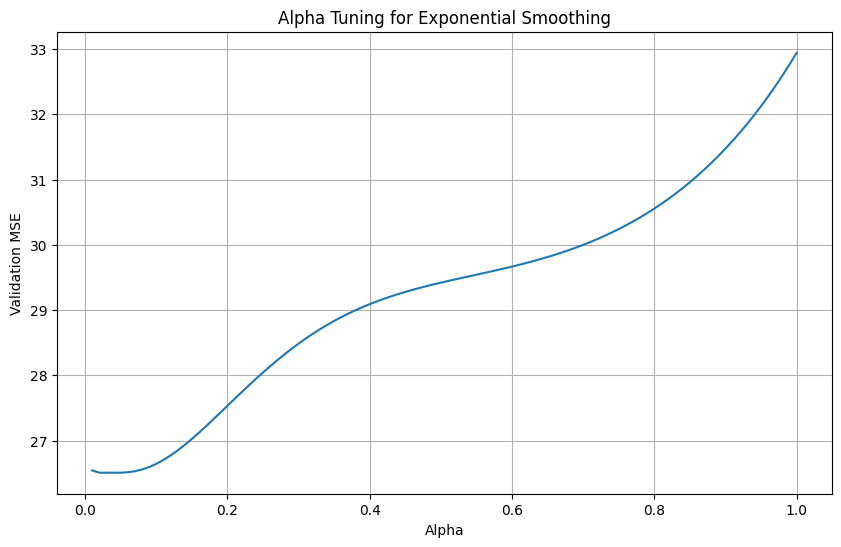

In [16]:
# Convert return series to numpy array
series = np.asarray(es['return_pct'])

# Split into train and validation sets (80% train, 20% validation)
train_size = int(len(series) * 0.8)
train, val = series[:train_size], series[train_size:]

# Define alpha grid (100 evenly spaced values between 0.01 and 1.0)
alphas = np.linspace(0.01, 1.0, 100)
errors = []

# Perform grid search
for alpha in alphas:
    model = SimpleExpSmoothing(train).fit(smoothing_level=alpha, optimized=False)
    forecast = model.forecast(len(val))
    mse = mean_squared_error(val, forecast)
    errors.append(mse)

# Select best alpha
best_alpha = alphas[np.argmin(errors)]
print(f"Best alpha: {best_alpha:.4f}, MSE: {min(errors):.4f}")

# Visualize MSE vs alpha
plt.figure(figsize=(10,6))
plt.plot(alphas, errors)
plt.xlabel('Alpha')
plt.ylabel('Validation MSE')
plt.title('Alpha Tuning for Exponential Smoothing')
plt.grid(True)
plt.show()

Part 4: Apply Best alpha, Detect Final Anomalies

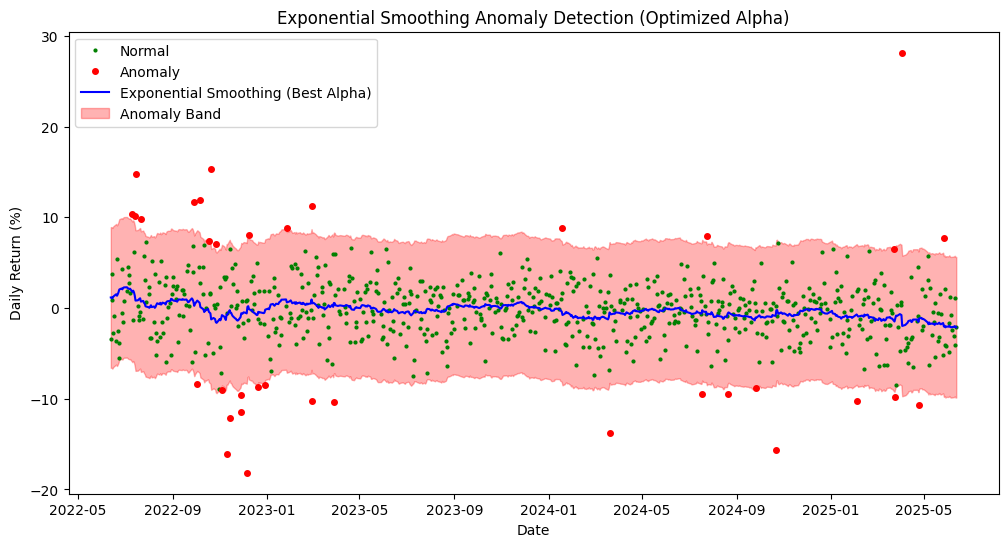

In [17]:
# Re-fit model using best alpha on full dataset
final_model = SimpleExpSmoothing(series).fit(smoothing_level=best_alpha, optimized=False)

# Apply fitted values
es['EMA'] = final_model.fittedvalues

# Calculate residuals
es['residual'] = es['return_pct'] - es['EMA']

# Build new adaptive bands
residual_std = es['residual'].std()
es['upper'] = es['EMA'] + 2 * residual_std
es['lower'] = es['EMA'] - 2 * residual_std

# Identify final anomalies
es['anomaly'] = (es['return_pct'] > es['upper']) | (es['return_pct'] < es['lower'])

# Visualize final detection
plt.figure(figsize=(12,6))

plt.plot(es.index[es['anomaly'] == False], es['return_pct'][es['anomaly'] == False], 'go', markersize=2, label='Normal')
plt.plot(es.index[es['anomaly'] == True], es['return_pct'][es['anomaly'] == True], 'ro', markersize=4, label='Anomaly')
plt.plot(es.index, es['EMA'], 'b-', label='Exponential Smoothing (Best Alpha)')
plt.fill_between(es.index, es['lower'], es['upper'], color='red', alpha=0.3, label='Anomaly Band')

plt.title("Exponential Smoothing Anomaly Detection (Optimized Alpha)")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")
plt.legend()
plt.show()

In [18]:
# Show anomalies
es_outliers = es[es['anomaly'] == True]

es_outliers

,return_pct,smoothed,residual,upper,lower,anomaly,EMA
Date,,,,,,,
2025-05-27,7.664110,-2.023855,9.712734,5.701899,-9.799147,True,-2.048624
2025-04-25,-10.725319,-0.128084,-9.575416,6.600620,-8.900426,True,-1.149903
2025-04-03,28.131748,-3.420604,30.116731,5.765540,-9.735506,True,-1.984983
2025-03-25,-9.808020,-1.558421,-8.660643,6.603145,-8.897901,True,-1.147378
2025-03-24,6.461641,-3.208341,7.955444,6.256720,-9.244326,True,-1.493803
2025-02-03,-10.222542,-0.005355,-9.504736,7.032717,-8.468329,True,-0.717806
2024-10-22,-15.625292,0.875623,-15.368797,7.494028,-8.007018,True,-0.256495
2024-09-25,-8.818037,-1.367832,-7.759817,6.692303,-8.808743,True,-1.058220
2024-08-20,-9.512544,-0.350615,-8.896360,7.134339,-8.366707,True,-0.616184


Model Justification:

In the Exponential Smoothing (ES) model, anomaly detection was applied to the daily return series of Pop Mart stock. The initial model used a fixed smoothing parameter (alpha = 0.2), which responded more heavily to short-term fluctuations, leading to wider prediction bands and more detected anomalies. To improve model accuracy, alpha tuning was performed by minimizing the mean squared error (MSE) on a validation set. The optimal alpha of 0.04 was selected, which produced a much smoother trend line and narrower prediction bands. This refinement allowed the model to better capture the underlying trend of returns while reducing sensitivity to normal short-term volatility, resulting in fewer but more meaningful anomalies. The Exponential Smoothing model is well-suited for this stock return data because it adaptively weighs recent and historical returns, effectively filtering noise while highlighting significant deviations from expected behavior.

### 4.3 Seasonal-Trend Decomposition (STD)

Part 1: Prepare Data for STD

In [19]:
# Make a copy of df to prepare for STL/STD analysis
std = df.copy()

# Select only Daily Return column
std = std[['Daily Return (%)']].dropna()

# Rename column for simplicity
std = std.rename(columns={'Daily Return (%)': 'return_pct'})

# Make sure index is datetime (important for seasonal_decompose)
std.index = pd.to_datetime(std.index)

# Check the result
std.head()

,return_pct
Date,
2025-06-12,-2.127660
2025-06-11,1.124438
2025-06-10,-4.077094
2025-06-09,-3.091190
2025-06-06,-2.392344


Part 2: Perform Seasonal-Trend Decomposition

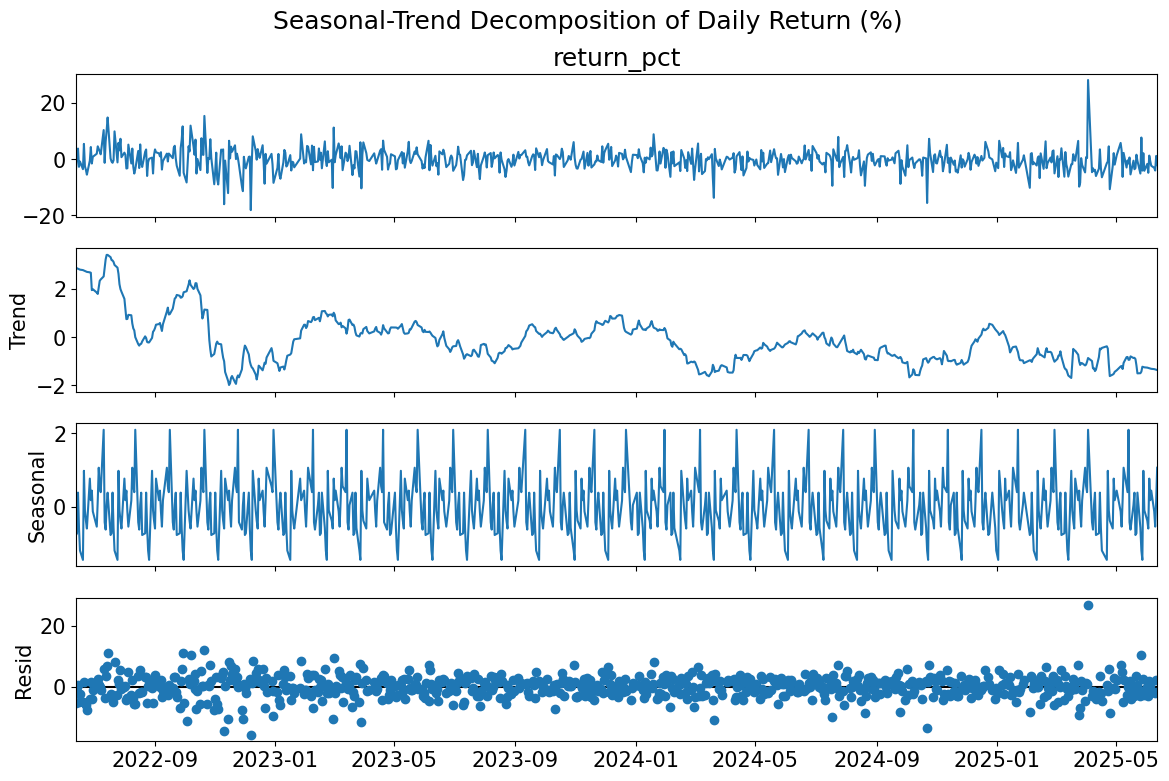

In [20]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Make a copy for decomposition to avoid modifying original data
std_decomp = std.copy(deep=True)

# Ensure index is datetime and sorted
std_decomp = std_decomp.sort_index()

# Set default plot style
plt.rc('figure', figsize=(12, 8))
plt.rc('font', size=15)

# Apply seasonal decomposition with extrapolation to reduce NaN on boundaries
result = sm.tsa.seasonal_decompose(
    std_decomp['return_pct'],
    model='additive',
    period=24,                 # 24 observations ≈ 1 month period (5 trading days per week)
    extrapolate_trend=24
)

# Save decomposition components back to dataframe
std_decomp['trend'] = result.trend
std_decomp['seasonal'] = result.seasonal
std_decomp['residual'] = result.resid

# Plot decomposition result
fig = result.plot()
plt.subplots_adjust(top=0.9)
plt.suptitle("Seasonal-Trend Decomposition of Daily Return (%)", fontsize=18)
plt.show()

Part 3: Anomaly Detection Based on Residuals

In [21]:
# Calculate residual mean and standard deviation
res_mean = result.resid.mean()
res_std = result.resid.std()

# Define upper and lower thresholds (± 2 standard deviations)
upper_limit = res_mean + 2 * res_std
lower_limit = res_mean - 2 * res_std

print(f"Upper limit: {upper_limit:.4f}")
print(f"Lower limit: {lower_limit:.4f}")

Upper limit: 7.3010
Lower limit: -7.3902


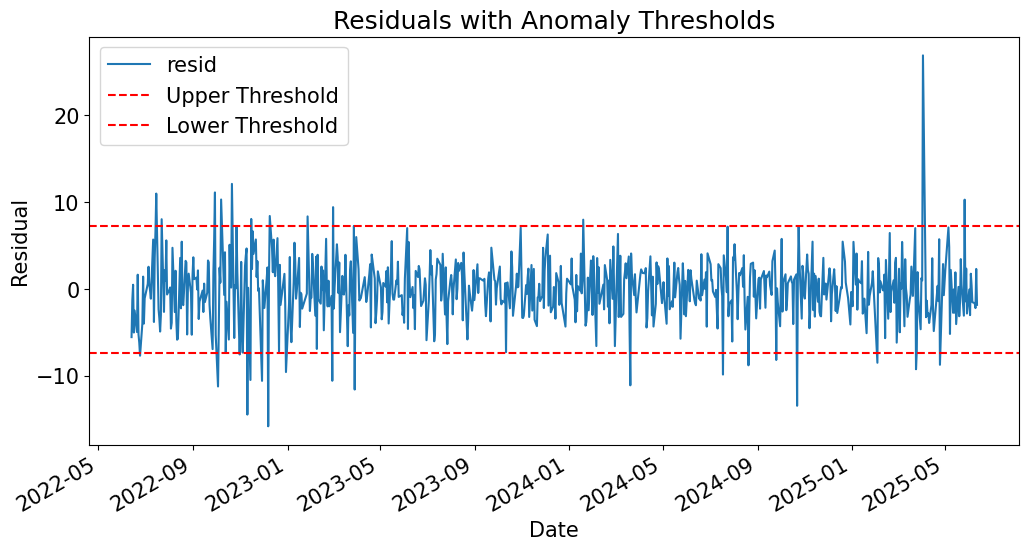

In [22]:
# Visualize the residuals and thresholds
result.resid.plot(figsize=(12,6))
plt.axhline(upper_limit, color='r', linestyle='--', label='Upper Threshold')
plt.axhline(lower_limit, color='r', linestyle='--', label='Lower Threshold')
plt.title("Residuals with Anomaly Thresholds")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.show()

In [23]:
# Identify anomalies where residuals exceed the thresholds
std_decomp['residual'] = result.resid  # (re-store residual if not already stored)

# Apply anomaly detection rule
std_decomp['anomaly'] = (
    (std_decomp['residual'] > upper_limit) | 
    (std_decomp['residual'] < lower_limit)
)

# Extract anomalies
std_outliers = std_decomp[std_decomp['anomaly'] == True]

# Show result
rows, cols = std_outliers.shape
print(f"\nTotal anomalies detected: {rows} rows, {cols} columns")

# Display first few anomalies
std_outliers.head()


Total anomalies detected: 31 rows, 5 columns


,return_pct,trend,seasonal,residual,anomaly
Date,,,,,
2022-06-24,-5.554386,2.712095,-0.591709,-7.674773,True
2022-07-15,14.799087,3.419858,0.383892,10.995337,True
2022-07-22,9.854604,3.000528,-1.190194,8.044270,True
2022-09-29,11.635287,1.697309,-1.190194,11.128172,True
2022-10-03,-8.331796,1.905723,0.979238,-11.216758,True


Model Justification:

The Seasonal-Trend Decomposition (STD) model effectively breaks down the daily return series into trend, seasonal, and residual components, revealing important characteristics of the Pop Mart stock behavior. The decomposition shows a long-term fluctuating trend alongside noticeable short-term seasonal patterns, likely related to monthly investor behavior or trading cycles. The residuals capture random fluctuations after removing these components, which serve as the basis for anomaly detection. By applying a ±2 standard deviation threshold on the residuals, significant deviations from normal return patterns are identified as anomalies. This approach is justified because it isolates irregular events that cannot be explained by the regular trend or seasonality, allowing us to detect abnormal price movements while accounting for the stock’s inherent structure.

### 4.4 Prophet Model

Part 1: Prepare Data for Prophet

In [45]:
# Subset full dataframe for 2024-05 to 2025-05 period
df = df.reset_index()
df['Date'] = pd.to_datetime(df['Date'])
df_sub = df[(df['Date'] >= '2024-05-01') & (df['Date'] <= '2025-05-31')].copy()

# Prepare Prophet-ready dataset
prophet = df_sub[['Date', 'Adj Close']].rename(columns={'Date':'ds', 'Adj Close':'y'})

# Show the subset
prophet.head()

,ds,y
10,2025-05-30,220.400
11,2025-05-29,225.000
12,2025-05-28,215.785
13,2025-05-27,232.323
14,2025-05-26,220.368


Part 2: Fit Prophet Model and Forecast

In [46]:
import numpy as np

np.random.seed(637)

from prophet import Prophet

# No random_state parameter
model = Prophet(daily_seasonality=True)
model.fit(prophet)

# Forecast using full historical data (no extra future periods)
future = model.make_future_dataframe(periods=0, freq='D')
forecast = model.predict(future)

# Check forecast results
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head()

19:33:36 - cmdstanpy - INFO - Chain [1] start processing
19:33:36 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
0,2024-05-02,34.383210,27.046991,41.292794
1,2024-05-03,34.755142,27.875554,42.213707
2,2024-05-06,33.913290,26.811134,40.617529
3,2024-05-07,34.788526,27.935020,41.680552
4,2024-05-08,34.726868,27.703681,41.424081


Part 3: Visualize Forecast and Components

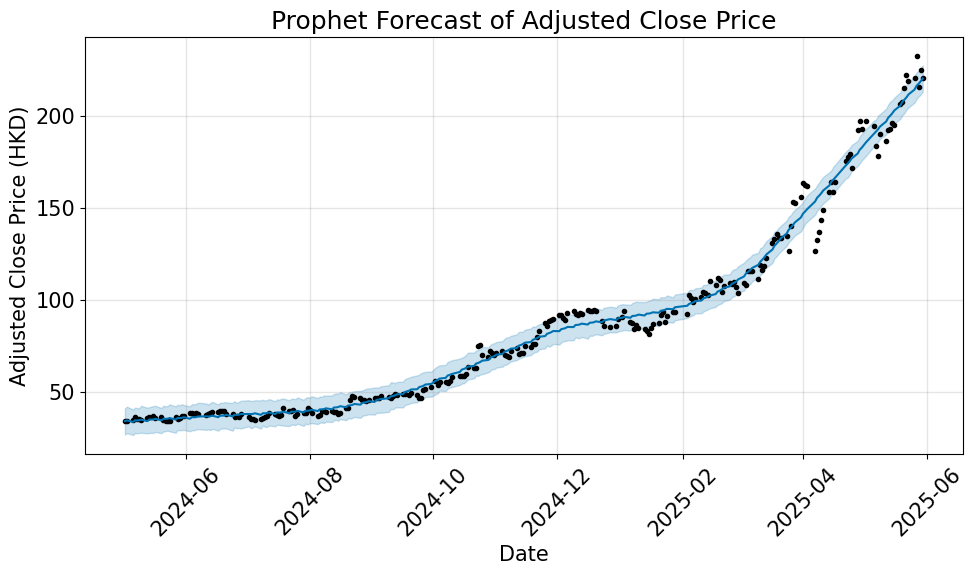

In [47]:
from prophet.plot import plot_plotly, plot_components_plotly
import matplotlib.pyplot as plt

# Forecast Plot
fig1 = model.plot(forecast)
plt.title("Prophet Forecast of Adjusted Close Price")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price (HKD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

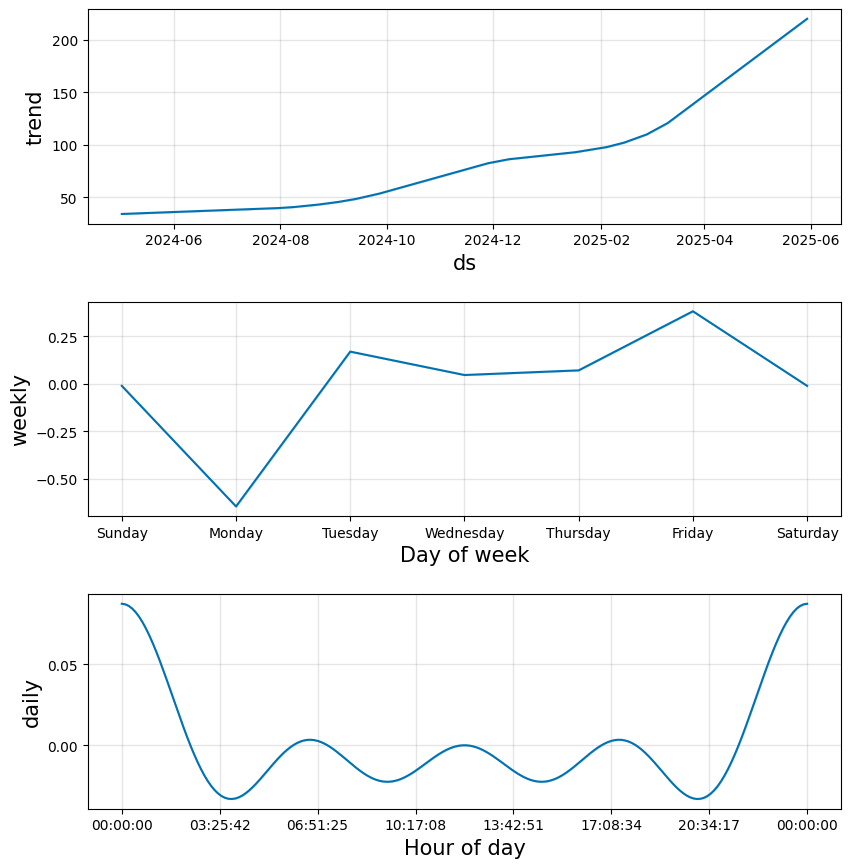

In [48]:
# Plot decomposed components
fig2 = model.plot_components(forecast)

# Adjust font sizes for better presentation
for ax in fig2.get_axes():
    plt.sca(ax)
    plt.xticks(fontsize=10)    # Reduce x-axis label font size
    plt.yticks(fontsize=10)    # Reduce y-axis label font size
    ax.title.set_fontsize(10)  # Reduce title font size

plt.show()

Part 4: Anomaly Detection Using Forecast Residuals

Total anomalies detected: 41 rows


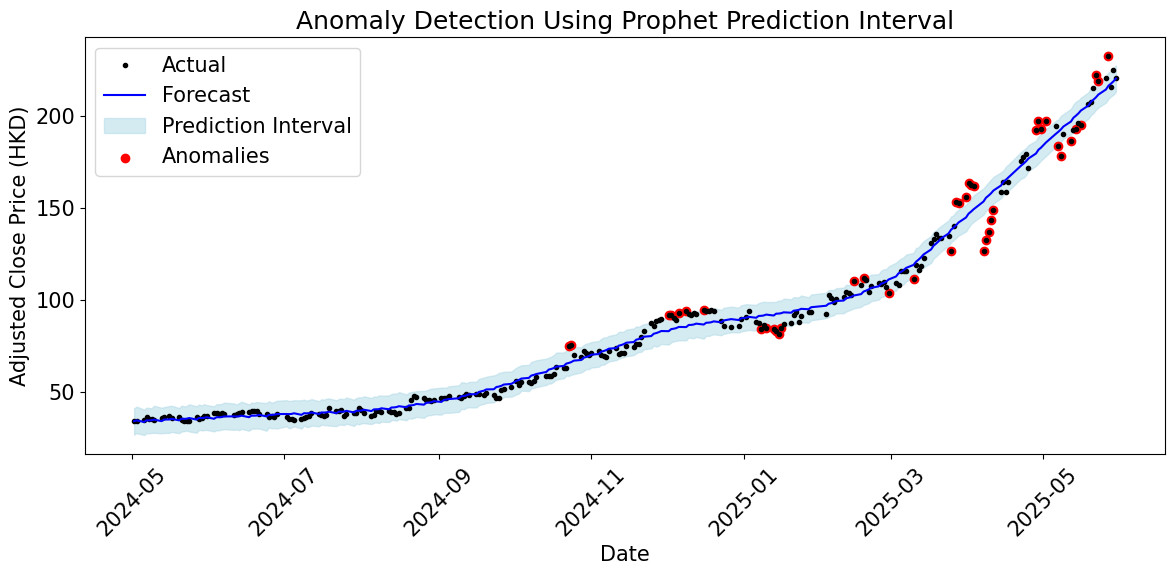

In [49]:
# Merge forecast with original data
merged = pd.merge(prophet, forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], on='ds')

# Define anomalies: points outside prediction intervals
merged['anomaly'] = (merged['y'] > merged['yhat_upper']) | (merged['y'] < merged['yhat_lower'])

# Extract anomalies
anomalies = merged[merged['anomaly']]
print(f"Total anomalies detected: {len(anomalies)} rows")

# Plot anomalies together with forecast
plt.figure(figsize=(12,6))

plt.plot(merged['ds'], merged['y'], 'k.', label='Actual')
plt.plot(merged['ds'], merged['yhat'], 'b-', label='Forecast')
plt.fill_between(merged['ds'], merged['yhat_lower'], merged['yhat_upper'], color='lightblue', alpha=0.5, label='Prediction Interval')
plt.scatter(anomalies['ds'], anomalies['y'], color='red', label='Anomalies')

plt.title("Anomaly Detection Using Prophet Prediction Interval")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price (HKD)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

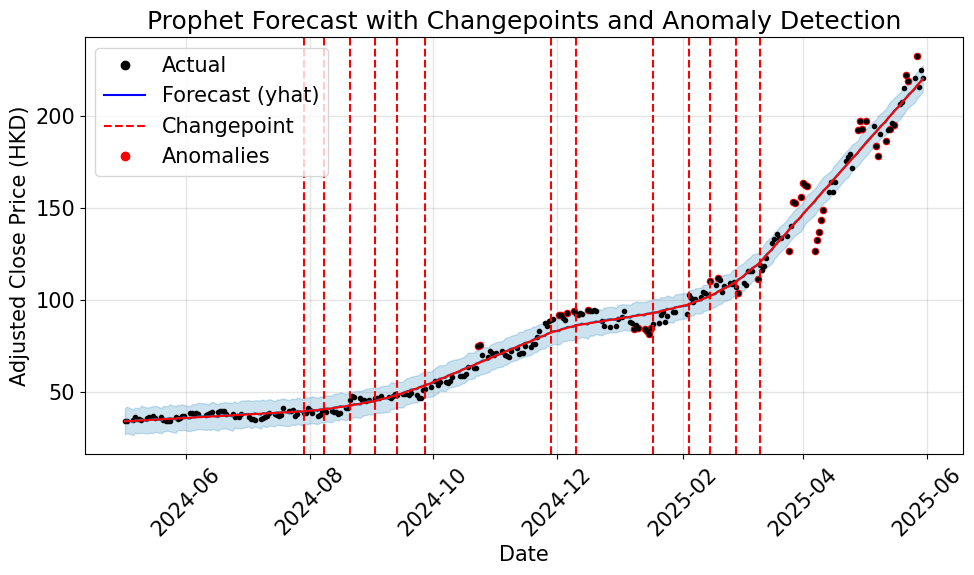

In [50]:
from prophet.plot import add_changepoints_to_plot
from matplotlib.lines import Line2D

fig = model.plot(forecast)
ax = fig.gca()

# Add changepoint lines
add_changepoints_to_plot(ax, model, forecast)

# Add anomalies
ax.scatter(anomalies['ds'], anomalies['y'], color='red', s=20, label='Anomalies')

# Custom legend
legend_elements = [
    Line2D([0], [0], color='black', marker='o', linestyle='None', label='Actual'),
    Line2D([0], [0], color='blue', label='Forecast (yhat)'),
    Line2D([0], [0], color='red', linestyle='--', label='Changepoint'),
    Line2D([0], [0], color='red', marker='o', linestyle='None', label='Anomalies')
]
ax.legend(handles=legend_elements, loc='upper left')

plt.title("Prophet Forecast with Changepoints and Anomaly Detection")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price (HKD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Part 5: Prophet Diagnostics (Cross-Validation)

19:38:35 - cmdstanpy - INFO - Chain [1] start processing  | 0/2 [00:00<?, ?it/s]
19:38:35 - cmdstanpy - INFO - Chain [1] done processing
19:38:35 - cmdstanpy - INFO - Chain [1] start processing[00:00<00:00,  8.83it/s]
19:38:35 - cmdstanpy - INFO - Chain [1] done processing
100%|█████████████████████████████████████████████| 2/2 [00:00<00:00, 12.57it/s]
/opt/anaconda3/envs/Anomalydetection/lib/python3.12/site-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/opt/anaconda3/envs/Anomalydetection/lib/python3.12/site-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


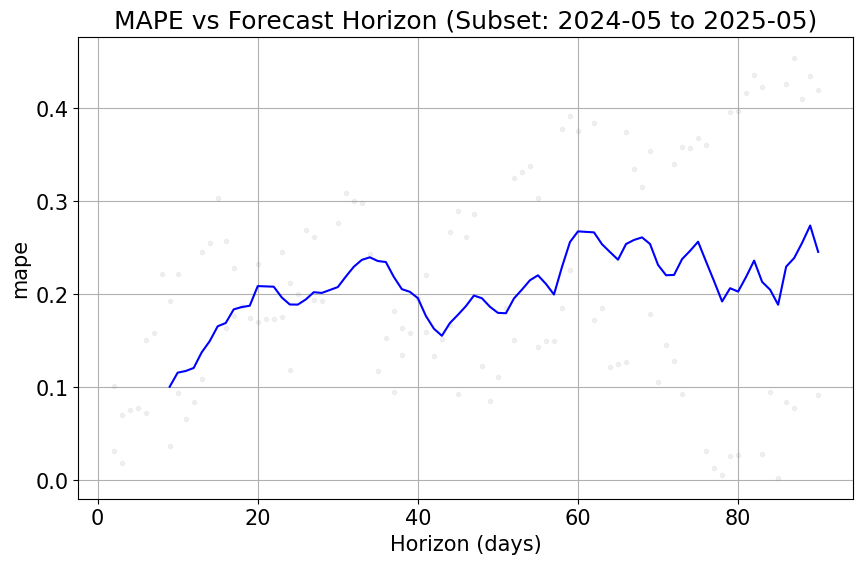

In [51]:
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
import matplotlib.pyplot as plt

# Cross Validation
prophet_cv = cross_validation(
    model, 
    initial='200 days',  
    period='60 days',    
    horizon='90 days'    
)

# Performance Metrics
prophet_perf = performance_metrics(prophet_cv)
prophet_perf.head()

# Plot MAPE vs Horizon
fig = plot_cross_validation_metric(prophet_cv, metric='mape')
plt.title("MAPE vs Forecast Horizon (Subset: 2024-05 to 2025-05)")
plt.show()

Model Justification:

The Prophet model was applied directly to the adjusted closing price using a focused subset from May 2024 to May 2025, where the stock experienced sharp price acceleration. This subset allowed Prophet’s additive model structure to better capture recent nonlinear growth patterns, changepoints, and fluctuations. The model successfully identified multiple changepoints corresponding to sudden shifts in growth rates and flagged anomalies when observed prices exceeded the forecast confidence interval. Diagnostic evaluation based on cross-validation showed that Prophet’s predictive accuracy remained reasonably stable across short-to-medium forecast horizons, with MAPE values generally between 10% and 30%. While this level of accuracy is acceptable for highly volatile stock data, forecast errors still tend to increase slightly as the horizon extends, reflecting increasing uncertainty in long-term forecasting rather than model deficiency. Overall, Prophet provided valuable interpretability for recent structural changes but may benefit from complementary models (e.g., deep learning) for improved precision in highly dynamic markets.

### Conclusion

In this project, we applied four different time series anomaly detection models to the historical stock price data of Pop Mart, using data from June 2022 to June 2025. Each model used different input variables and detection methods, allowing us to analyze both short-term fluctuations and longer-term structural changes in the stock’s behavior.

Simple Moving Average (SMA)

- Dataset used: Raw Adjusted Close Price.
- Anomaly detection method: SMA was used to smooth price fluctuations using a 24-day moving window, capturing the local trend. Adaptive rolling standard deviation of residuals was applied to build dynamic upper and lower bands for anomaly detection. Data points outside these bands were flagged as anomalies.
- Limitations: SMA assumes a fixed smoothing window, making it less responsive to rapid market shifts or structural breaks. It does not capture seasonality or non-linear trend changes, and may underperform during sharp market rallies or crashes.

Exponential Smoothing (ES)

- Dataset used: Daily Return (%).
- Anomaly detection method: Exponential smoothing assigns higher weights to recent returns, generating a smoothed curve. Anomalies were detected by calculating residuals between observed returns and smoothed predictions, with thresholds defined by ±2 standard deviations.
- Limitations: ES focuses only on short-term fluctuations and lacks decomposition into trend or seasonality. Its performance highly depends on the optimized smoothing parameter (alpha), and may not capture sudden regime shifts or long-term changes effectively.

Seasonal-Trend Decomposition (STD)

- Dataset used: Daily Return (%).
- Anomaly detection method: STD decomposed the return series into trend, seasonal, and residual components. Anomalies were identified by analyzing residuals outside ±2 standard deviation bounds.
- Limitations: STD assumes additive structure and fixed seasonal patterns, which may not fully capture the non-periodic or irregular behavior often observed in stock return data. It may also generate many missing values for short sample sizes due to rolling decomposition.

Prophet Model

- Dataset used: Raw Adjusted Close Price.  (May 2024 to May 2025)
- Anomaly detection method: Prophet decomposed the price series into trend, seasonal, and changepoint components. Anomalies were identified when actual prices fell outside Prophet’s prediction intervals. Prophet also detected changepoints representing significant shifts in stock growth trends.
- Limitations: Prophet works best for time series with clear seasonal or calendar-based patterns, which are weak in stock prices. Model diagnostics showed that forecasting accuracy declines as the forecast horizon extends, with MAPE rising from approximately 10–20% for short-term horizons to 30%+ for longer-term forecasts, reflecting the inherent unpredictability of stock market movements rather than model flaws.

Future Modeling Suggestions

While the models used in this study provided valuable insights into anomalies and trend shifts in Pop Mart stock price, stock price forecasting remains highly challenging due to market volatility, news shocks, and nonlinear behaviors. To improve forecasting accuracy for such financial data, in future research, I may explore more advanced deep learning models that can capture complex temporal dependencies, such as:

- Recurrent Neural Networks (RNN)
- Long Short-Term Memory networks (LSTM)
- Gated Recurrent Units (GRU)
- Attention-based architectures (Transformers)

These models are better suited for capturing long-term dependencies, sudden regime shifts, and non-linear price movements often seen in financial markets.